In [363]:
import pandas as pd

In [364]:
df=pd.read_csv('task1_dataset.csv')
df

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,2020-01-01,63,63013.191704,2.793898e+05,616.029633,31,6.904324e+05,Bangalore,Unemployed,Auto,294319.227774
1,2020-01-02,20,47161.859481,9.508975e+05,716.561294,33,5.951086e+05,Bangalore,Student,Home,154516.648673
2,2020-01-03,46,55234.345094,NaN,564.991196,28,9.989912e+05,Delhi,Student,Auto,252354.507062
3,2020-01-04,52,74712.765160,4.311590e+05,572.736033,25,7.007800e+05,Chennai,Unemployed,Home,226719.203929
4,2020-01-05,56,82830.588108,2.727301e+05,813.630055,34,1.105784e+06,Delhi,Unemployed,Home,225838.346929
...,...,...,...,...,...,...,...,...,...,...,...
1995,2025-06-18,41,70630.379654,1.525158e+06,732.884459,31,5.963429e+05,Hyderabad,Salaried,Home,300442.168194
1996,2025-06-19,41,63361.024697,3.055093e+05,546.198231,33,9.203431e+05,Delhi,Salaried,Auto,289954.022081
1997,2025-06-20,50,60798.190941,2.596022e+05,639.065695,27,6.858628e+05,Delhi,Unemployed,Home,195312.531902
1998,2025-06-21,35,56771.242421,3.296667e+05,578.375678,34,1.133484e+06,Mumbai,Unemployed,Education,263439.565538


In [365]:
# remove date column
df = df.drop('date', axis=1)
df.head()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,63,63013.191704,279389.811431,616.029633,31,6.904324e+05,Bangalore,Unemployed,Auto,294319.227774
1,20,47161.859481,950897.454063,716.561294,33,5.951086e+05,Bangalore,Student,Home,154516.648673
2,46,55234.345094,NaN,564.991196,28,9.989912e+05,Delhi,Student,Auto,252354.507062
3,52,74712.765160,431159.014692,572.736033,25,7.007800e+05,Chennai,Unemployed,Home,226719.203929
4,56,82830.588108,272730.054365,813.630055,34,1.105784e+06,Delhi,Unemployed,Home,225838.346929


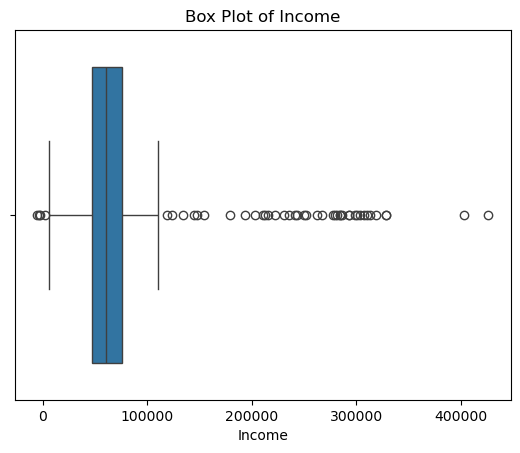

In [366]:
from matplotlib import pyplot as plt
import seaborn as sns
sns.boxplot(df['income'], orient='h')
plt.title('Box Plot of Income')
plt.xlabel('Income')    
plt.show()

In [367]:
df.isnull().sum()

age                  0
income              80
loan_amount         80
credit_score        80
num_transactions     0
annual_spend        80
city                 0
employment_type      0
loan_type            0
target               0
dtype: int64

In [368]:
# fill missing values in income column with median
df['income'] = df['income'].fillna(df['income'].median())


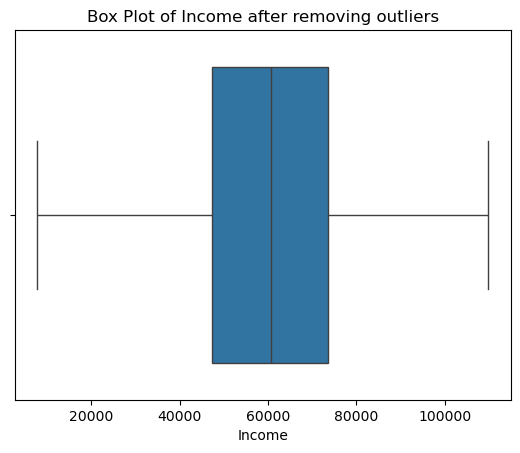

In [369]:
# remove outliers in income column
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['income'] >= lower_bound) & (df['income'] <= upper_bound)]
sns.boxplot(df['income'], orient='h')
plt.title('Box Plot of Income after removing outliers')
plt.xlabel('Income')    
plt.show()

In [370]:
# fill missing values in loan_amount column with median
df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].median())


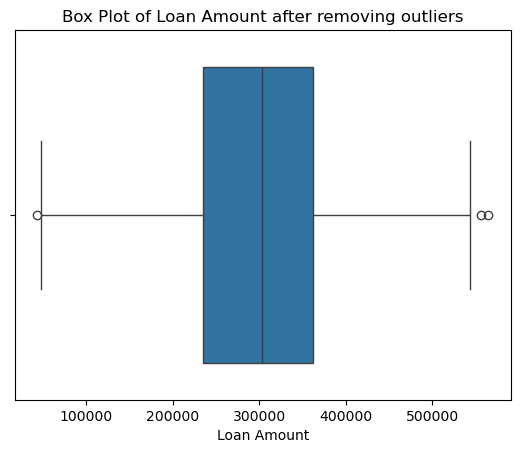

In [371]:
# handle outliers in loan_amount column using IQR method
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['loan_amount'] >= lower_bound) & (df['loan_amount'] <= upper_bound)]
sns.boxplot(df['loan_amount'], orient='h')
plt.title('Box Plot of Loan Amount after removing outliers')    
plt.xlabel('Loan Amount')
plt.show()

In [372]:
df.describe()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target
count,1902.000000,1902.000000,1902.000000,1827.000000,1902.000000,1.823000e+03,1902.000000
mean,43.501052,60187.561542,299465.713865,649.123446,30.139853,1.077725e+06,246357.315293
std,14.905268,19057.001090,94072.153032,80.559417,5.244812,6.826044e+05,65528.226930
min,18.000000,8374.393888,43823.666722,373.096400,14.000000,-1.461650e+05,13300.170171
25%,31.000000,47136.131723,235020.190902,594.086093,27.000000,7.881944e+05,202937.134577
50%,43.000000,60602.715999,303202.869860,649.462713,30.000000,1.004689e+06,245424.498558
75%,56.000000,73600.057570,362423.495682,702.801629,34.000000,1.215135e+06,291302.392474
max,69.000000,109905.509202,564851.335096,919.903709,52.000000,7.541094e+06,478502.472525


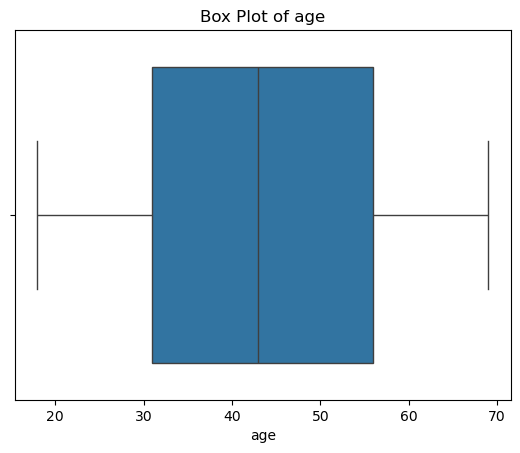

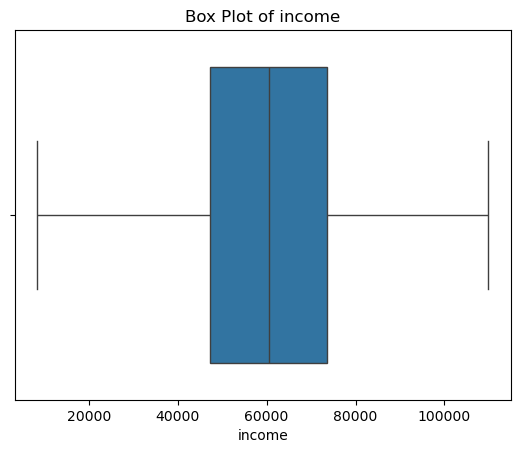

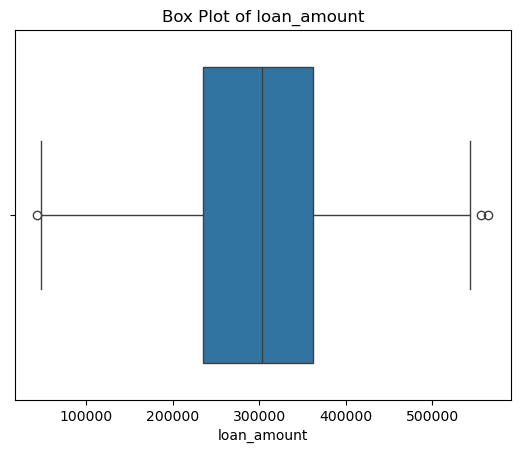

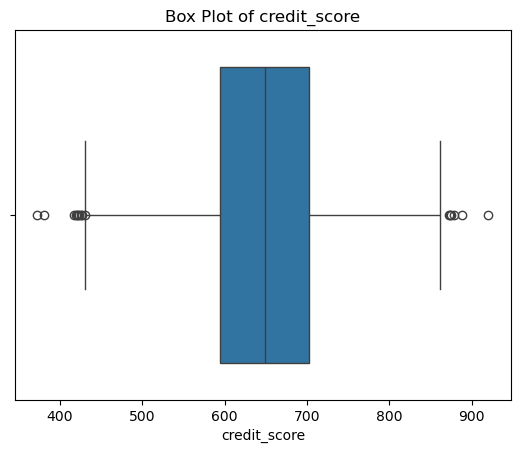

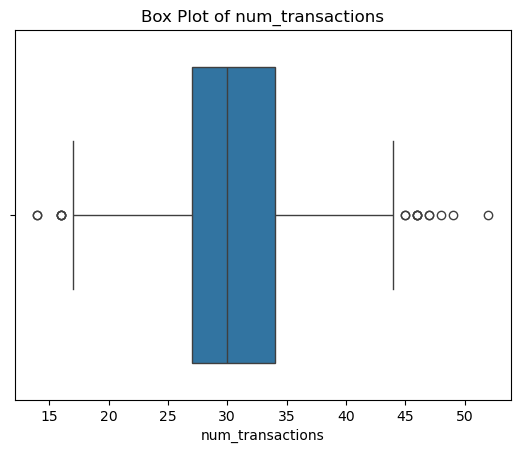

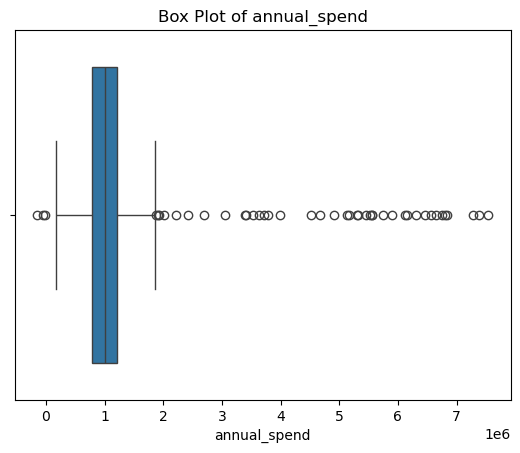

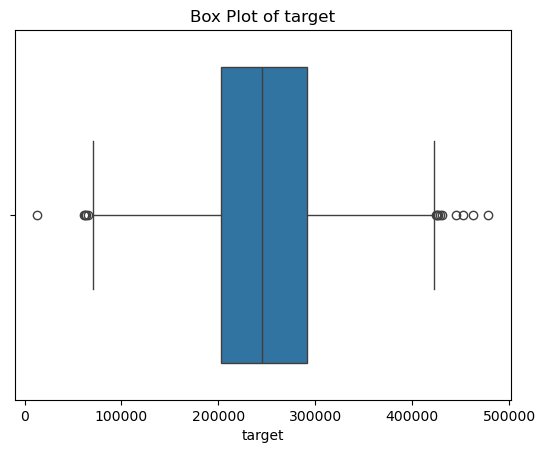

In [373]:
# plot boxplot of all numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    sns.boxplot(df[col], orient='h')
    plt.title(f'Box Plot of {col}')    
    plt.xlabel(col)
    plt.show()

In [374]:
df.isnull().sum()

age                  0
income               0
loan_amount          0
credit_score        75
num_transactions     0
annual_spend        79
city                 0
employment_type      0
loan_type            0
target               0
dtype: int64

In [375]:
# fill missing values in credit_score column with median
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())

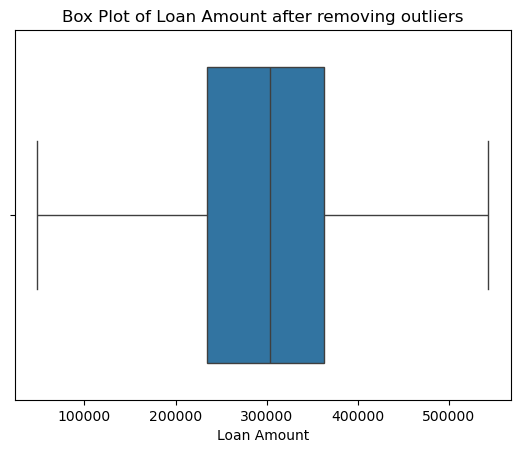

In [376]:
# handle outliers in loan_amount column
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['loan_amount'] >= lower_bound) & (df['loan_amount'] <= upper_bound)]
sns.boxplot(df['loan_amount'], orient='h')
plt.title('Box Plot of Loan Amount after removing outliers')    
plt.xlabel('Loan Amount')
plt.show()

In [377]:
# fill missing values of annual_spend column with median
df['annual_spend'] = df['annual_spend'].fillna(df['annual_spend'].median())


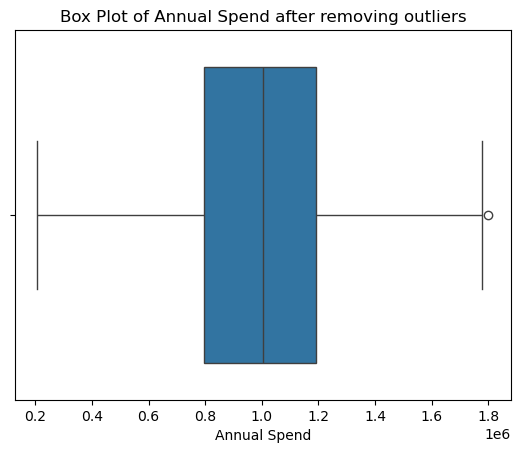

In [378]:
# remove outliers in annual_spend column
Q1 = df['annual_spend'].quantile(0.25)
Q3 = df['annual_spend'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['annual_spend'] >= lower_bound) & (df['annual_spend'] <= upper_bound)]
sns.boxplot(df['annual_spend'], orient='h')
plt.title('Box Plot of Annual Spend after removing outliers')
plt.xlabel('Annual Spend')
plt.show()

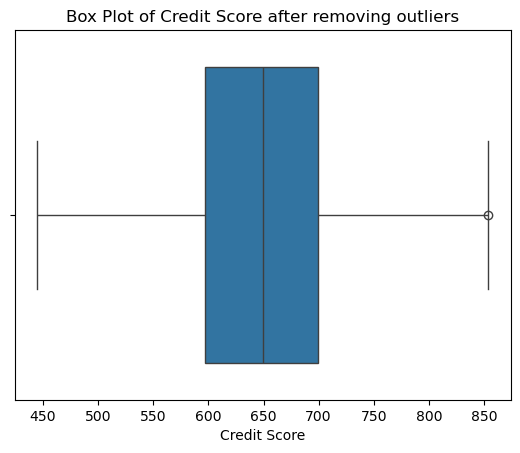

In [379]:
# remove the outliers in credit_score column    
Q1 = df['credit_score'].quantile(0.25)
Q3 = df['credit_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['credit_score'] >= lower_bound) & (df['credit_score'] <= upper_bound)]
sns.boxplot(df['credit_score'], orient='h')
plt.title('Box Plot of Credit Score after removing outliers')    
plt.xlabel('Credit Score')
plt.show()

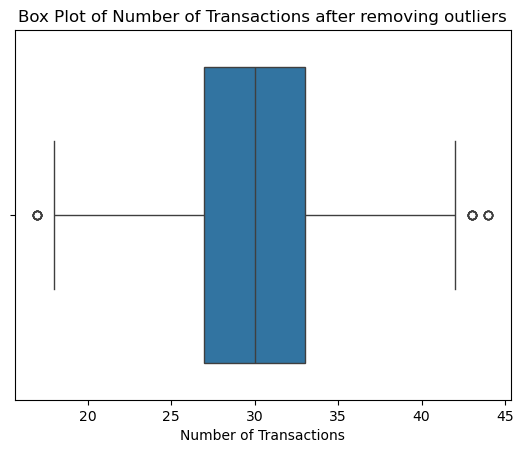

In [380]:
# remove outliers in num_transactions column
Q1 = df['num_transactions'].quantile(0.25)
Q3 = df['num_transactions'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['num_transactions'] >= lower_bound) & (df['num_transactions'] <= upper_bound)]
sns.boxplot(df['num_transactions'], orient='h')
plt.title('Box Plot of Number of Transactions after removing outliers')
plt.xlabel('Number of Transactions')
plt.show()

In [381]:
df.describe()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target
count,1817.000000,1817.000000,1817.000000,1817.000000,1817.000000,1.817000e+03,1817.000000
mean,43.492020,60150.254664,299725.176420,649.535568,30.099064,9.939681e+05,246270.779962
std,14.897375,19161.374570,93691.543932,75.095511,5.047689,2.862480e+05,64791.008384
min,18.000000,8374.393888,48403.405030,444.821463,17.000000,2.071887e+05,61880.080954
25%,31.000000,47104.487238,234947.802900,596.789844,27.000000,7.943120e+05,203090.714537
50%,43.000000,60602.715999,303202.869860,649.462713,30.000000,1.004858e+06,245327.140872
75%,56.000000,73614.059704,362425.851057,699.418170,33.000000,1.191098e+06,290815.972049
max,69.000000,109905.509202,543218.624116,853.894730,44.000000,1.799912e+06,478502.472525


In [382]:
df.head()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,63,63013.191704,279389.811431,616.029633,31,6.904324e+05,Bangalore,Unemployed,Auto,294319.227774
2,46,55234.345094,303202.869860,564.991196,28,9.989912e+05,Delhi,Student,Auto,252354.507062
3,52,74712.765160,431159.014692,572.736033,25,7.007800e+05,Chennai,Unemployed,Home,226719.203929
4,56,82830.588108,272730.054365,813.630055,34,1.105784e+06,Delhi,Unemployed,Home,225838.346929
5,35,51850.084382,358787.410069,653.483969,44,1.060460e+06,Bangalore,Self-Employed,Education,222714.888194


In [383]:
df['city'].unique()


array(['Bangalore', 'Delhi', 'Chennai', 'Hyderabad', 'Mumbai'],
      dtype=object)

In [ ]:
df['employment_type'].unique()


array(['Unemployed', 'Student', 'Self-Employed', 'Salaried'], dtype=object)

In [385]:
df['loan_type'].unique()

array(['Auto', 'Home', 'Education', 'Personal'], dtype=object)

In [386]:
# use one-hot encoding to convert categorical variables into numerical variables
df = pd.get_dummies(df, columns=['city', 'employment_type', 'loan_type'])
df.head()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,loan_type_Auto,loan_type_Education,loan_type_Home,loan_type_Personal
0,63,63013.191704,279389.811431,616.029633,31,6.904324e+05,294319.227774,True,False,False,False,False,False,False,False,True,True,False,False,False
2,46,55234.345094,303202.869860,564.991196,28,9.989912e+05,252354.507062,False,False,True,False,False,False,False,True,False,True,False,False,False
3,52,74712.765160,431159.014692,572.736033,25,7.007800e+05,226719.203929,False,True,False,False,False,False,False,False,True,False,False,True,False
4,56,82830.588108,272730.054365,813.630055,34,1.105784e+06,225838.346929,False,False,True,False,False,False,False,False,True,False,False,True,False
5,35,51850.084382,358787.410069,653.483969,44,1.060460e+06,222714.888194,True,False,False,False,False,False,True,False,False,False,True,False,False


In [387]:
# convert true to 1 and false to 0 in boolean columns of the dataset
mapping = {True: 1, False: 0}
for col in df.select_dtypes(include=['bool']).columns:
    df[col] = df[col].map(mapping)
df.head()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,loan_type_Auto,loan_type_Education,loan_type_Home,loan_type_Personal
0,63,63013.191704,279389.811431,616.029633,31,6.904324e+05,294319.227774,1,0,0,0,0,0,0,0,1,1,0,0,0
2,46,55234.345094,303202.869860,564.991196,28,9.989912e+05,252354.507062,0,0,1,0,0,0,0,1,0,1,0,0,0
3,52,74712.765160,431159.014692,572.736033,25,7.007800e+05,226719.203929,0,1,0,0,0,0,0,0,1,0,0,1,0
4,56,82830.588108,272730.054365,813.630055,34,1.105784e+06,225838.346929,0,0,1,0,0,0,0,0,1,0,0,1,0
5,35,51850.084382,358787.410069,653.483969,44,1.060460e+06,222714.888194,1,0,0,0,0,0,1,0,0,0,1,0,0


In [388]:
# use min-max scaling to scale the numerical columns
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numerical_cols = ['credit_score', 'income', 'loan_amount', 'annual_spend', 'num_transactions']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()


,age,income,loan_amount,credit_score,num_transactions,annual_spend,target,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,loan_type_Auto,loan_type_Education,loan_type_Home,loan_type_Personal
0,63,0.538148,0.466813,0.418527,0.518519,0.303407,294319.227774,1,0,0,0,0,0,0,0,1,1,0,0,0
2,46,0.461533,0.514939,0.293761,0.407407,0.497138,252354.507062,0,0,1,0,0,0,0,1,0,1,0,0,0
3,52,0.653380,0.773532,0.312694,0.296296,0.309904,226719.203929,0,1,0,0,0,0,0,0,1,0,0,1,0
4,56,0.733334,0.453354,0.901571,0.629630,0.564188,225838.346929,0,0,1,0,0,0,0,0,1,0,0,1,0
5,35,0.428201,0.627273,0.510086,1.000000,0.535731,222714.888194,1,0,0,0,0,0,1,0,0,0,1,0,0


In [389]:
from sklearn.model_selection import train_test_split
X = df.drop('target', axis=1)
y= df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [390]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred = model.predict(X_test)
y_pred

array([299526.87714319, 186859.84581732, 186911.41909861, 264414.00012293,
       177096.57444075, 269912.68909427, 207961.78372662, 231441.8012831 ,
       264758.87134507, 179803.65086052, 315513.04313731, 304953.08240768,
       253122.9204567 , 199725.72144386, 279309.08869967, 190481.21906671,
       230093.95519943, 328335.61589138, 258307.48921336, 242244.43727889,
       208459.16556383, 288852.39315279, 229941.29263082, 288634.86811693,
       216730.39040529, 188409.26152702, 253511.81638915, 287750.38641482,
       292761.16352819, 196181.85490148, 255077.85488126, 229010.99612202,
       226023.25875306, 281278.14513444, 281898.55511609, 218159.70698186,
       232778.53251307, 214272.39275088, 225446.77893733, 270760.21011017,
       274723.37636755, 254769.21353519, 233419.25262069, 217058.69790775,
       267959.27296048, 157117.69445786, 293982.56312438, 174308.88661163,
       202240.15891006, 234029.32674628, 269431.9000219 , 254743.23080195,
       229574.58151808, 2

In [392]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R2 Score: {r2}')


Mean Squared Error: 2569361603.947971
R2 Score: 0.3882049105868195


In [393]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred1 = model.predict(X_test)

In [394]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred1)
r2 = r2_score(y_test, y_pred1)
print(f'Mean Squared Error: {mse}')
print(f'R2 Score: {r2}')

Mean Squared Error: 5709589683.13981
R2 Score: -0.3595201723812431


In [398]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=10)
model.fit(X_train, y_train)
y_pred3 = model.predict(X_test)


In [399]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred3)
r2 = r2_score(y_test, y_pred3)
print(f'Mean Squared Error: {mse}')
print(f'R2 Score: {r2}')

Mean Squared Error: 4112785933.4628196
R2 Score: 0.020697501654146633


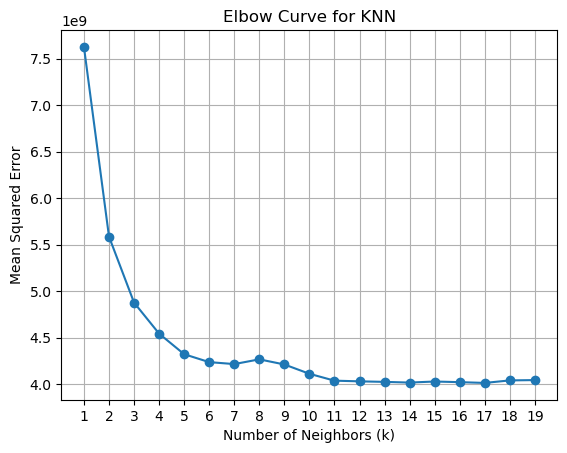

In [400]:
# plot elbow curve to find optimal value of k for KNN
mse_values = []
k_values = range(1, 20)
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    mse_k = mean_squared_error(y_test, y_pred_k)
    mse_values.append(mse_k)
plt.plot(k_values, mse_values, marker='o')
plt.title('Elbow Curve for KNN')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Squared Error')
plt.xticks(k_values)
plt.grid()